FIRST 5 ROWS:

   Age Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  Genital thrush visual blurring Itching Irritability delayed healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes           No             Yes   
4             No             Yes     Yes          Yes             Yes   

  partial paresis muscle stiffness Alopecia Obesity     class  
0              No        

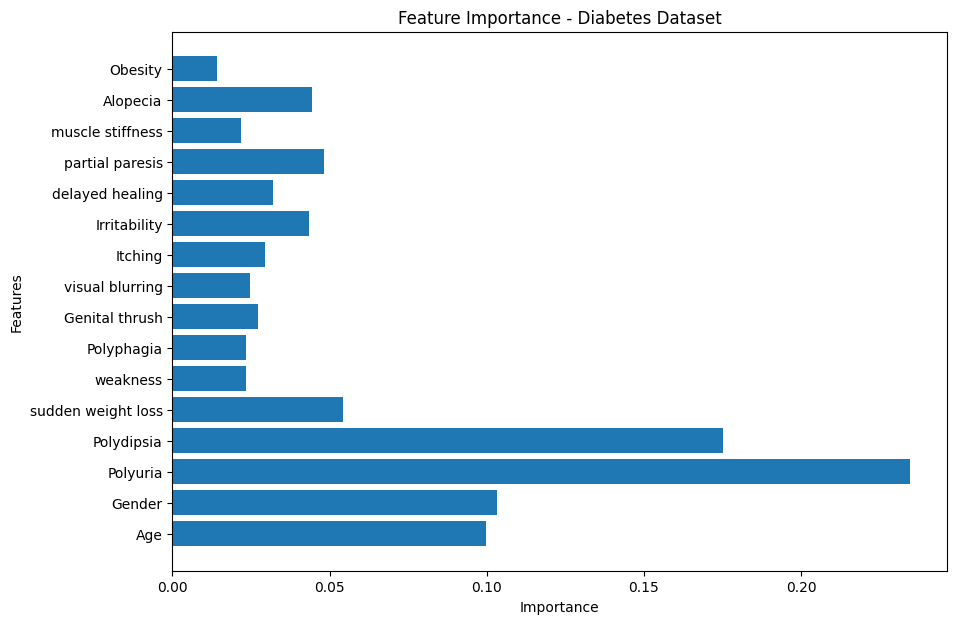


GRAPH SAVED SUCCESSFULLY!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("../datasets/diabetes.csv")

# =========================
# SHOW DATA
# =========================

print("FIRST 5 ROWS:\n")
print(df.head())

print("\nDATASET INFO:\n")
print(df.info())

print("\nMISSING VALUES:\n")
print(df.isnull().sum())

# =========================
# CONVERT TEXT TO NUMBERS
# =========================

df = df.replace({
    'Yes': 1,
    'No': 0,
    'Positive': 1,
    'Negative': 0,
    'Male': 1,
    'Female': 0
})

# Convert all columns to numeric
df = df.apply(pd.to_numeric)

# =========================
# FEATURES AND TARGET
# =========================

X = df.drop("class", axis=1)
y = df["class"]

# =========================
# TRAIN TEST SPLIT
# 80% TRAINING
# 20% TESTING
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# MODEL
# =========================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# =========================
# TRAIN MODEL
# =========================

model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================

y_pred = model.predict(X_test)

# =========================
# ACCURACY
# =========================

accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY:\n")
print(accuracy)

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX:\n")
print(cm)

# =========================
# CLASSIFICATION REPORT
# =========================

print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# =========================
# FEATURE IMPORTANCE GRAPH
# =========================

importance = model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(10, 7))

plt.barh(feature_names, importance)

plt.xlabel("Importance")
plt.ylabel("Features")

plt.title("Feature Importance - Diabetes Dataset")

# SAVE GRAPH
plt.savefig("../graphs/diabetes_feature_importance.png")

plt.show()

print("\nGRAPH SAVED SUCCESSFULLY!")